In [ ]:
!pip install datasets
!pip install torch
!pip install transformers
!pip install pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 14.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("ashraq/fashion-product-images-small", split="train")

# Display the first record
print(dataset[0])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/867 [00:00<?, ?B/s]

(…)-00000-of-00002-6cff4c59f91661c3.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

(…)-00001-of-00002-bb459e5ac5f01e71.parquet:   0%|          | 0.00/135M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44072 [00:00<?, ? examples/s]

{'id': 15970, 'gender': 'Men', 'masterCategory': 'Apparel', 'subCategory': 'Topwear', 'articleType': 'Shirts', 'baseColour': 'Navy Blue', 'season': 'Fall', 'year': 2011.0, 'usage': 'Casual', 'productDisplayName': 'Turtle Check Men Navy Blue Shirt', 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80 at 0x7BB1E97A40A0>}


In [ ]:
import re

def extract_brand(record):
    brand = None
    if record.get('productDisplayName'):
        brand = record['productDisplayName'].split(" ")[0]  # Assuming the first word is the brand

    return brand

# Apply the extraction function to the dataset
dataset = dataset.map(lambda x: {'brand': extract_brand(x)})

# Display the updated dataset
print(dataset[0])

Map:   0%|          | 0/44072 [00:00<?, ? examples/s]

{'id': 15970, 'gender': 'Men', 'masterCategory': 'Apparel', 'subCategory': 'Topwear', 'articleType': 'Shirts', 'baseColour': 'Navy Blue', 'season': 'Fall', 'year': 2011.0, 'usage': 'Casual', 'productDisplayName': 'Turtle Check Men Navy Blue Shirt', 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80 at 0x7BB1EDA79F30>, 'brand': 'Turtle'}


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
import base64
from PIL import Image

# Helper function to encode image to base64
def encode_image(image):
    import io
    buffered = io.BytesIO()
    image.save(buffered, format="JPEG")
    return base64.b64encode(buffered.getvalue()).decode("utf-8")

# Filter and transform the dataset
def transform(record):

    if record['brand'] and record['image']:
        return {
            "name": record['productDisplayName'],
            "brand": record['brand'],
            "image": encode_image(record['image'])
        }
    return None

# Apply the transformation
filtered_data = [
    transform(record) for record in dataset
    if transform(record) is not None
]

# Save the filtered dataset as a JSON file
output_path = "/content/drive/My Drive/filtered_dataset-fpis.json"
with open(output_path, "w") as json_file:
    json.dump(filtered_data, json_file, indent=4)

print(f"Filtered dataset has been saved to {output_path}")

Filtered dataset has been saved to /content/drive/My Drive/filtered_dataset-fpis.json


In [ ]:
print(filtered_data[0])

{'name': 'Turtle Check Men Navy Blue Shirt', 'brand': 'Turtle', 'image': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCABQADwDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwD3+iiigBK88+IXxRsvBYOnwxG51eSLzI48fJGCcAuc/Xgeleh14x4o8HT6j8WrrU57Rb20FokiQn+IgbNvP4monNQV2VGLk7

In [ ]:
from transformers import CLIPProcessor, CLIPModel
import torch
import pickle
import base64
from PIL import Image
import os
import json
from io import BytesIO

# Path to the filtered dataset JSON file
filtered_dataset_path = "/content/drive/My Drive/filtered_dataset-fpis.json"

# Load the filtered dataset
with open(filtered_dataset_path, "r") as f:
    filtered_data = json.load(f)

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

# Helper function to decode base64 image
def decode_base64_image(base64_string):
    try:
        image_data = base64.b64decode(base64_string)
        image = Image.open(BytesIO(image_data)).convert("RGB")
        return image
    except Exception as e:
        print(f"Error decoding base64 image: {e}")
        return None

# Compute embeddings and store metadata
embeddings = []
metadata = []

for i in range(12000, 36000):
    record = filtered_data[i]
    image_base64 = record["image"]
    if image_base64:
        try:
            # Decode the base64 image
            image = decode_base64_image(image_base64)
            if image is None:
                continue

            # Prepare the image for the model
            inputs = processor(images=image, return_tensors="pt")
            with torch.no_grad():
                embedding = model.get_image_features(**inputs).squeeze().numpy()

            # Store the embedding and metadata
            embeddings.append(embedding)
            metadata.append({
                "name": record["name"],
                "brand": record["brand"],
                "image": image_base64
            })
        except Exception as e:
            print(f"Error processing image {image}: {e}")

# Save embeddings and metadata as a pickle file
output_pickle_path = "/content/drive/My Drive/image_embeddings_fpis.pkl"

# Check if the pickle file exists
if os.path.exists(output_pickle_path):
    # Load existing data
    with open(output_pickle_path, "rb") as f:
        existing_data = pickle.load(f)
    existing_embeddings = existing_data.get("embeddings", [])
    existing_metadata = existing_data.get("metadata", [])
else:
    # Initialize empty data if the file doesn't exist
    existing_embeddings = []
    existing_metadata = []

# Append new embeddings and metadata
combined_embeddings = existing_embeddings + embeddings
combined_metadata = existing_metadata + metadata

# Save the updated data back to the pickle file
with open(output_pickle_path, "wb") as f:
    pickle.dump({"embeddings": combined_embeddings, "metadata": combined_metadata}, f)

print(f"Embeddings and metadata have been saved to {output_pickle_path}")


Embeddings and metadata have been saved to /content/drive/My Drive/image_embeddings_fpis.pkl


In [ ]:
output_pickle_path = "/content/drive/My Drive/image_embeddings_fpis.pkl"

with open(output_pickle_path, "rb") as f:
    data = pickle.load(f)

print(f"Number of embeddings: {len(data['embeddings'])}")
print(f"Embedding{data['embeddings'][0]}")
print(f"Metadata: {data['metadata'][0]}")


Number of embeddings: 36000
Embedding[ 9.81015712e-02  2.06205100e-01 -2.06768632e-01  4.69929464e-02
 -1.47371009e-01  6.51396927e-04 -9.29876119e-02 -5.78342676e-01
  3.14813197e-01  1.43483460e-01  1.10813156e-01  4.17132229e-01
  5.80778122e-01  4.65649039e-01 -6.60895824e-01  2.33545259e-01
  1.56458902e+00  2.58990228e-01  1.45360470e-01  5.78434058e-02
  5.64466119e-01 -2.86209196e-01  7.16558695e-01 -6.32830977e-01
 -1.23574853e-01  4.38271940e-01  2.88685441e-01 -3.15120876e-01
  2.84635313e-02 -3.01286966e-01  6.28626585e-01 -2.29451999e-01
 -5.80953583e-02 -2.54703313e-01  3.52453440e-01 -3.51686448e-01
  5.53850718e-02  3.25137407e-01 -9.08608735e-01  1.38050008e+00
 -1.34620070e-01 -9.77990106e-02 -1.13752186e-01 -6.36356547e-02
 -2.97149122e-01  8.65449756e-02 -3.92931700e-01  3.17396045e-01
  4.85423625e-01 -2.83297628e-01  3.10908109e-01  6.45378828e-02
 -1.78082392e-01 -5.04487641e-02 -3.56543735e-02 -1.96470216e-01
 -1.80235833e-01 -6.17042035e-02 -6.73951805e-01  4.2

Please upload an image file:


Saving adidas-image1.jpg to adidas-image1.jpg

Query Image:


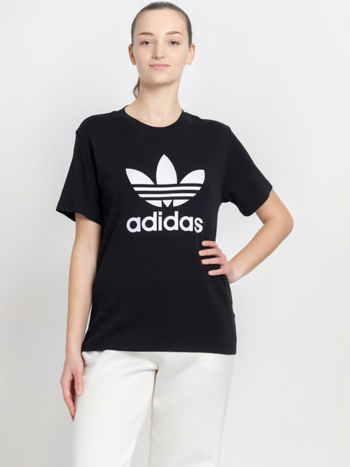


Predicted Brand: Adidas

Top 5 Similar Images with the Predicted Brand:

Match 1:
  Name: Adidas Men Black Shorts


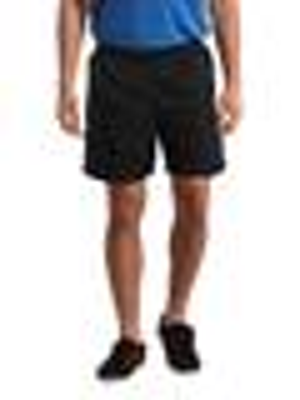


Match 2:
  Name: Adidas Men White Polo T-shirt


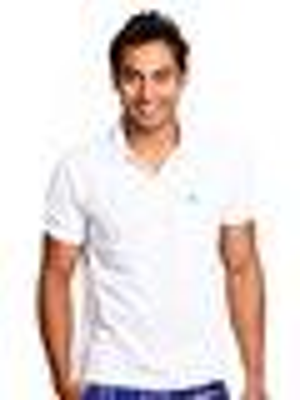


Match 3:
  Name: Adidas Men Stripe Polo Shirt


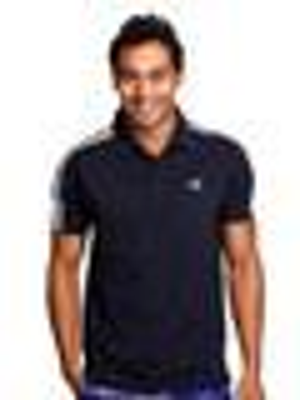


Match 4:
  Name: Adidas Men 3 Stripe Green Polo T-shirt


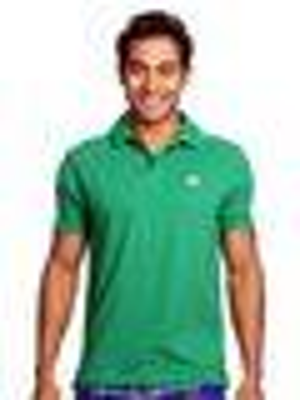


Match 5:
  Name: Adidas Men Blue Polo T-shirt


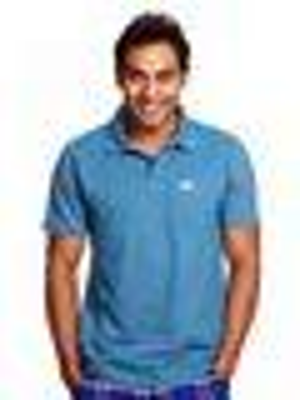

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
from google.colab import files
import base64
from io import BytesIO
import pickle
from IPython.display import display

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

# Predefined brand names for brand prediction
brands = ["Nike", "Adidas", "Puma", "Fastrack", "Levis", "Jockey"]

# Load precomputed embeddings and metadata
pickle_file_path = "/content/drive/My Drive/image_embeddings_fpis.pkl"
with open(pickle_file_path, "rb") as f:
    data = pickle.load(f)

stored_embeddings = data["embeddings"]
stored_metadata = data["metadata"]

# Helper function to decode base64-encoded images
def decode_base64_image(base64_string):
    image_data = base64.b64decode(base64_string)
    return Image.open(BytesIO(image_data)).convert("RGB")

# Helper function to display images with a custom width
def display_image_with_width(image, width):
    aspect_ratio = image.height / image.width
    new_height = int(width * aspect_ratio)
    resized_image = image.resize((width, new_height))
    display(resized_image)

# Step 1: Upload the query image
print("Please upload an image file:")
uploaded = files.upload()
query_image_path = list(uploaded.keys())[0]
query_image = Image.open(query_image_path).convert("RGB")

# Step 2: Predict the brand of the query image
# Process the query image with the predefined brand names
inputs = processor(text=brands, images=query_image, return_tensors="pt", padding=True)

# Extract image and text inputs
image_inputs = inputs["pixel_values"]  # For images
text_inputs = inputs["input_ids"]      # For text

# Compute embeddings for the query image and brand names
with torch.no_grad():
    image_embeds = model.get_image_features(pixel_values=image_inputs)
    text_embeds = model.get_text_features(input_ids=text_inputs)

# Convert embeddings to numpy arrays
image_embeds = image_embeds.cpu().numpy()
text_embeds = text_embeds.cpu().numpy()

# Compute similarity to predict the brand
similarities = cosine_similarity(image_embeds, text_embeds)
predicted_brand = brands[similarities.argmax()]

# Display the query image and the predicted brand
print("\nQuery Image:")
display_image_with_width(query_image, width=350)
print(f"\nPredicted Brand: {predicted_brand}")

# Step 3: Find similar images with the same brand
# Compute embedding for the query image
def compute_query_embedding(image):
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        embedding = model.get_image_features(**inputs).squeeze().numpy()
    return embedding

query_embedding = compute_query_embedding(query_image)

# Compute cosine similarity with stored embeddings
similarities = cosine_similarity([query_embedding], stored_embeddings)[0]

# Sort indices by similarity
sorted_indices = similarities.argsort()[::-1]  # Descending order

# Filter images with the predicted brand
filtered_indices = [index for index in sorted_indices if stored_metadata[index]['brand'] == predicted_brand]

# Get the top 5 similar images with the predicted brand
top_indices = filtered_indices[:5]

# Step 4: Display the top 5 similar images
print("\nTop 5 Similar Images with the Predicted Brand:")
for i, index in enumerate(top_indices):
    meta = stored_metadata[index]
    print(f"\nMatch {i+1}:")
    print(f"  Name: {meta['name']}")
    decoded_image = decode_base64_image(meta['image'])
    display_image_with_width(decoded_image, width=300)